# Implementation details
This implementation will follow the standard Canny edge detection algorithm:
1. Smooth the image
2. Compute gradients, magnitude, and orientation of the gradient
3. Perform non-maximum suppression
4. Apply hysteresis thresholding 

# Ingest image
Read a grascale image and store it in a matrix $I$

float64
[[ 40.  42.  35. ...  12.  10.  11.]
 [ 61.  63.  59. ...  12.  10.  11.]
 [ 57.  58.  56. ...  11.  11.  11.]
 ...
 [ 96. 120. 126. ...  25.  29.  24.]
 [123. 128. 127. ...  32.  28.  23.]
 [132. 127. 123. ...  30.  27.  24.]]


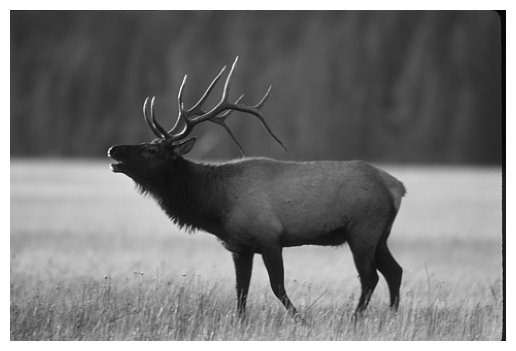

In [63]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image as a 2D grayscale, store floats
img_path = 'images/elk.jpg'
I = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
I = I.astype(np.float64)

# Output basic info
print(I.dtype)
print(I)
# Display with matplotlib
plt.imshow(I, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

# Construct the Gaussian derivative

Pre-differentiating the Gaussian offers significant speed improvements.

These calculations provide a single filter kernel that can be convolved with the image.

## Why pre-differentiate?

Smoothing with a Gaussian $G$ and then differentiating is the same as convolving once with the derivative of the Gaussian:

$$
\frac{\partial}{\partial x}\,(G * I) \;=\; \left(\frac{\partial G}{\partial x}\right) * I
$$

So instead of two passes (blur, then differentiate), we build one kernel $\frac{\partial G}{\partial x}$ ahead of time and apply it once.

## Step 1: Sample positions

The Gaussian never reaches zero, so we truncate at $3\sigma$:

$$
r = \lceil 3\sigma \rceil, \qquad x \in \{-r, -r+1, \dots, 0, \dots, r-1, r\}
$$

The kernel has $2r + 1$ elements (7 when $\sigma = 1$).

## Step 2: Gaussian kernel

$$
G_{\text{raw}}(x) = \exp\!\left(-\frac{x^2}{2\sigma^2}\right)
$$

We normalize numerically so the weights sum to 1 (a true weighted average, so brightness is preserved):

$$
G(x) = \frac{G_{\text{raw}}(x)}{\sum_{k=-r}^{r} G_{\text{raw}}(k)}, \qquad \sum_{x} G(x) = 1
$$

## Step 3: Derivative kernel

Differentiating the Gaussian with the chain rule:

$$
\frac{d}{dx}\exp\!\left(-\frac{x^2}{2\sigma^2}\right)
= -\frac{x}{\sigma^2}\exp\!\left(-\frac{x^2}{2\sigma^2}\right)
$$

so, reusing the normalized $G$:

$$
\frac{dG}{dx}(x) = -\frac{x}{\sigma^2}\,G(x)
$$

## Step 4: Applying along each axis

The same 1D coefficients are used for both directions. The 2D Gaussian is separable, $G(x,y) = G(x)\,G(y)$, so:

$$
I_x = I * \left(\frac{dG}{dx}\ \text{along } x,\ \ G\ \text{along } y\right), \qquad
I_y = I * \left(G\ \text{along } x,\ \ \frac{dG}{dy}\ \text{along } y\right)
$$

Two 1D passes cost $O(N)$ per pixel instead of $O(N^2)$ for a full 2D kernel.

The gradient magnitude and direction used by Canny are then:

$$
|\nabla I| = \sqrt{I_x^2 + I_y^2}, \qquad \theta = \operatorname{atan2}(I_y,\, I_x)
$$

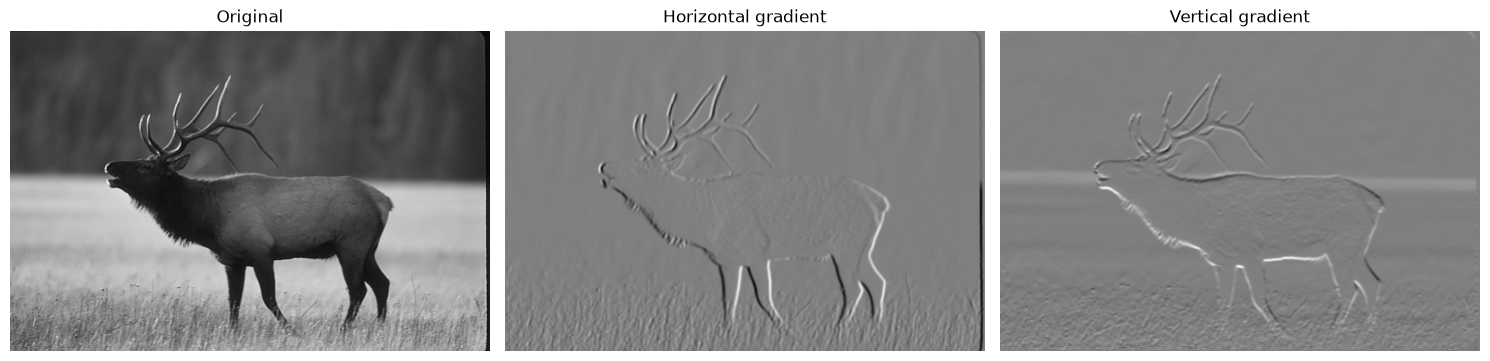

In [ ]:
sigma = 1.0
kernel_radius = int(np.ceil(3 * sigma))
# Generate numpy array within the kernel radius
x = np.arange(-kernel_radius, kernel_radius+1, dtype=np.float64)

# Normalize Gaussian kernel
G = np.exp(-x**2 / (2 * sigma**2))
G /= G.sum()

# Use the differentiated Gaussian
# G(x,y) = G(x)G(y), so the same 1D arrays serve both axes:
#   Ix: dG along x, G along y
#   Iy: dG along y, G along x
dG = -(x / sigma**2) * G


def convolve(image, kernel, axis):
    """
    Convolve a 2D image with a 1D kernel along a specified axis
      axis = 0 -> vertical   (neighbors above/below, same column)
      axis = 1 -> horizontal (neighbors left/right, same row)
    """
    height, width = image.shape
    kernel_length = len(kernel)
    kernel_radius = kernel_length // 2

    # Pad the borders
    # Pixels near the edge need neighbors that don't exist
    if axis == 0:
        padding = [(kernel_radius, kernel_radius), (0, 0)]
    else:
        padding = [(0, 0), (kernel_radius, kernel_radius)]

    padded = np.pad(image, padding, mode="reflect")

    # Flip the kernel to perform convolution
    flipped_kernel = kernel[ : : -1]

    result = np.zeros((height, width), dtype=np.float64)

    for k in range(kernel_length):
        weight = flipped_kernel[k]
        
        if axis == 0:
            shifted_image = padded[k : k + height, :]
        else:
            shifted_image = padded[:, k : k + width]

        # For each pixel, store weight * neighbor at this offset
        result += weight * shifted_image

    return result


# Vertical smoothing
Ix = convolve(I, G, axis=0)
# Horizontal smoothing
Iy = convolve(I, G, axis=1)

# Horizontal derivative
Ix_prime = convolve(Ix, dG, axis=1)
# Vertical derivative
Iy_prime = convolve(Iy, dG, axis=0)


# Plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(I, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original")
limit = max(np.abs(Ix_prime).max(), np.abs(Iy_prime).max())
axes[1].imshow(Ix_prime, cmap="gray", vmin=-limit, vmax=limit)
axes[1].set_title("Horizontal gradient")
axes[2].imshow(Iy_prime, cmap="gray", vmin=-limit, vmax=limit)
axes[2].set_title("Vertical gradient")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()
